# Inverse design optimization of a compact grating coupler

**This notebook contains a long optimization. Running the entire notebook will cost about 10 FlexCredits and take a few hours.**

The ability to couple light in and out of photonic integrated circuits (PICs) is crucial for developing wafer-scale systems and tests. This need makes designing efficient and compact grating couplers an important task in the PIC development cycle. In this notebook, we will demonstrate how to use `tidy3d` to perform the inverse design of a compact 3D grating coupler. We will show how to improve design fabricability by enhancing permittivity binarization and controlling the device's minimum feature size.

<img src="img/adjoint_6.png" width=400 alt="Schematic of the grating coupler">

In addition, if you are interested in more conventional designs, we modeled an [uniform grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/GratingCoupler/) and a [Focusing apodized grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/FocusedApodGC/) in previous case studies. For more integrated photonic examples, please visit our [examples page](https://www.flexcompute.com/tidy3d/examples/). If you are new to the finite-difference time-domain (FDTD) method, we highly recommend going through our [FDTD101](https://www.flexcompute.com/fdtd101/) tutorials. FDTD simulations can diverge due to various reasons. If you run into any simulation divergence issues, please follow the steps outlined in our [troubleshooting guide](https://www.flexcompute.com/tidy3d/examples/notebooks/DivergedFDTDSimulation/) to resolve it.

We start by importing our typical python packages, plus `autograd` and `tidy3d`.

In [167]:
# Standard python imports.
from typing import List

# Import autograd to be able to use automatic differentiation.
import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np
import scipy as sp

# Import regular tidy3d.
import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad

## Ian's Notes

Each iteration runs the simulation one time. Each iteration works as follows
1. Compute J(p) and dJ/dp
2. update p = p + (a)dJ/dp
3. run simulation again to compute J(p) and dJ/dp 

The objective function does the following in order
1. creates a simulation with the design region parameters at some p
2. runs the simulation and then calculates the FOM(figure of merit)
3. Subtracts the feature size penalty from the FOM and returns the value for J of that simulation

You pass this objective function into the value_and_grad function from the autograd function and that will calculate both your J(p) and the dJ/dp

## Design Parameters

In [168]:
 # Geometric parameters.
w_thick = 0.22  # Waveguide thickness (um).
w_width = 0.5  # Waveguide width (um).
w_length = 1.0  # Waveguide length (um).
box_thick = 0.752  # SiO2 BOX thickness (um).
spot_size = 1.5  # Spot size of the input Gaussian field regarding a lensed fiber (um).
fiber_tilt = 10.0  # Fiber tilt angle (degrees).
src_offset = 0.05  # Distance between the source focus and device (um).

# Material.
nSi = 3.695  # Silicon refractive index.
nSiO2 = 1.44  # Silica refractive index.
nSi3N4 = 2.03

# Design region parameters.
gc_width = 12.0  # Grating coupler width (um).
gc_length = 12.0  # Grating coupler length (um).
dr_grid_size = 0.02  # Grid size within the design region (um).

# Inverse design setup parameters.
# Total number of iterations = opt_steps x it_per_step.
it_per_step = 1  # Number of iterations per optimization step.
opt_steps = 41  # Number of optimization steps.

eta = 0.50  # Threshold value for the projection filter.
fom_name = "fom_field"  # Name of the monitor used to compute the objective function.
# Simulation wavelength.
wl = 0.729  # Central simulation wavelength (um).
bw = 0.02  # Simulation bandwidth (um).
n_wl = 10  # Number of wavelength points within the bandwidth.

# feature size
min_feature_size = 0.060
filter_radius = min_feature_size

# Buffer layer thickness
border_buffer = 0.16
# projection
beta_min = 1.0
beta_max = 30.0
total_iter = opt_steps * it_per_step
print(f"Total iterations = {total_iter}") 

# Minimum and maximum values for the permittivities.
eps_max = nSi3N4**2
eps_min = 1.0
eps_si = nSi**2
# Material definitions.
mat_si = td.Medium(permittivity=eps_si)  # Si bottom layer material.
mat_sio2 = td.Medium(permittivity=nSiO2**2)  # BOX material.
mat_si3n4 = td.Medium(permittivity=eps_max) # Waveguide material

# Wavelengths and frequencies.
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])
run_time = 5e-12

# Computational domain size.
pml_spacing = 0.6 * wl
size_x = pml_spacing + w_length + gc_length + 2 * border_buffer
size_y = gc_width + 2 * pml_spacing + 2 * border_buffer
size_z = w_thick + box_thick + 2 * pml_spacing
center_z = size_z / 2 - pml_spacing - w_thick / 2
eff_inf = 1000

# Inverse design variables.
src_pos_z = w_thick / 2 + src_offset
mon_pos_x = -size_x / 2 + 0.25 * wl
mon_w = int(3 * w_width / dr_grid_size) * dr_grid_size
mon_h = int(5 * w_thick / dr_grid_size) * dr_grid_size
nx = int((gc_length + 2 * border_buffer) / dr_grid_size)
ny = int((gc_width + 2 * border_buffer) / dr_grid_size / 2.0)
npar = int(nx * ny)
dr_size_x = nx * dr_grid_size
dr_size_y = 2 * ny * dr_grid_size
dr_center_x = -size_x / 2 + w_length + dr_size_x / 2
n_border = int(border_buffer / dr_grid_size) 

Total iterations = 41


## Structures, Monitors, Sources


In [169]:
 # Input/output waveguide.
waveguide = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -w_width / 2, -w_thick / 2),
        rmax=(-size_x / 2 + w_length, w_width / 2, w_thick / 2),
    ),
    medium=mat_si3n4,
)

# SiO2 BOX layer.
sio2_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -w_thick / 2 - box_thick),
        rmax=(eff_inf, eff_inf, -w_thick / 2),
    ),
    medium=mat_sio2,
)

# Si3N4 substrate.
si_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -eff_inf),
        rmax=(eff_inf, eff_inf, -w_thick / 2 - box_thick),
    ),
    medium=mat_si3n4,
)

# Source positioned at waveguide
new_source = td.ModeSource(
    center=[mon_pos_x,0,0], # Reuse the old mode monitor position
    size=[0,mon_w,mon_h],
    source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
    direction="+",  # Firing toward the grating coupler
    mode_spec=td.ModeSpec(num_modes=1, target_neff=nSi3N4),
    mode_index=0,
)

# Monitor where we will compute the objective function from.
z_surface = w_thick
z_monitor = z_surface + 0.20
field_near = td.FieldMonitor(
    center=(dr_center_x, 0, z_monitor),
    size=(dr_size_x, dr_size_y, 0),
    freqs=[freq],
    name="field_near",
) 

## Initial Parameters

In [170]:
init_par = np.random.uniform(0, 1, int(npar))
init_par = sp.ndimage.gaussian_filter(init_par, 1)
init_par = init_par.reshape((nx, ny))

## Get parameter values

In [171]:
def get_eps(design_param: np.ndarray, beta: float = 1.00, binarize: bool = False) -> np.ndarray:
    """Returns the permittivities after applying a conic density filter on design parameters
    to enforce fabrication constraints, followed by a binarization projection function
    which reduces grayscale.
    Parameters:
        design_param: np.ndarray
            Vector of design parameters.
        beta: float = 1.0
            Sharpness parameter for the projection filter.
        binarize: bool = False
            Enforce binarization.
    Returns:
        eps: np.ndarray
            Permittivity vector.
    """

    # Calculates the permittivities from the transformed design parameters.
    eps = get_eps_values(design_param, beta=beta)
    if binarize:
        eps = anp.where(eps < (eps_min + eps_max) / 2, eps_min, eps_max)
    else:
        eps = anp.where(eps < eps_min, eps_min, eps)
        eps = anp.where(eps > eps_max, eps_max, eps)
    return eps 

from tidy3d.plugins.autograd import make_filter_and_project, rescale

filter_project = make_filter_and_project(filter_radius, dr_grid_size, padding="constant")


def interface_buffer(params):
    """Introduce a buffer around design to enhance fabricability at the interfaces."""
    mask = anp.zeros_like(params)
    mask[0:n_border, :] = 0
    mask[nx - n_border :, :] = 0
    mask[:, ny - n_border :] = 0
    mask[0:n_border, 0 : int((w_width / 2) / dr_grid_size) + 1] = 1

    return params * (1 - mask) + mask


def pre_process(params, beta):
    """Get the permittivity values (1, eps_wg) array as a function of the parameters (0,1)"""
    params1 = interface_buffer(params)
    params2 = filter_project(params1, beta=beta)
    params3 = filter_project(params2, beta=beta)
    return params3


def get_eps_values(params: np.ndarray, beta: float) -> np.ndarray:
    """Get the relative permittivity array given the parameters."""
    params = pre_process(params, beta=beta)
    eps_values = rescale(params, eps_min, eps_max)
    return eps_values

## Update Design

In [172]:
def update_design(eps, unfold: bool = False) -> List[td.Structure]:
    """Reflects the structure about the x-axis."""
    nyii = ny
    y_min = 0
    dr_s_y = dr_size_y / 2
    dr_c_y = dr_s_y / 2
    eps_val = anp.array(eps).reshape((nx, ny, 1))
    if unfold:
        nyii = 2 * ny
        y_min = -dr_size_y / 2
        dr_s_y = dr_size_y
        dr_c_y = 0
        eps_val = anp.concatenate((anp.fliplr(anp.copy(eps_val)), eps_val), axis=1)

    # Definition of the coordinates x,y along the design region.
    coords_x = [(dr_center_x - dr_size_x / 2) + ix * dr_grid_size for ix in range(nx)]
    coords_y = [y_min + iy * dr_grid_size for iy in range(nyii)]
    coords = dict(x=coords_x, y=coords_y, z=[0])

    # Creation of a custom medium using the values of the design parameters.
    permittivity = td.SpatialDataArray(eps_val, coords=coords)
    eps_medium = td.CustomMedium(permittivity=permittivity)
    box = td.Box(center=(dr_center_x, dr_c_y, 0), size=(dr_size_x, dr_s_y, w_thick))
    design_structure = td.Structure(geometry=box, medium=eps_medium)
    return [design_structure]

## Make Simulation

In [173]:
def make_adjoint_sim(
    design_param: np.ndarray,
    beta: float = 1.00,
    unfold: bool = False,
    binarize: bool = False,
) -> td.Simulation:
    # Builds the design region from the design parameters.
    eps = get_eps(design_param, beta, binarize) # returns the permittivites in a binarized form, so anything from 1.0 to si3n4's permittivites, it converts the parameter psace of design_param into binarized permittivites
    design_structure = update_design(eps, unfold=unfold) # create a structure out of those binarized permittivities

    # Creates a uniform mesh for the design region.
    adjoint_dr_mesh = td.MeshOverrideStructure(
        geometry=td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, w_thick)),
        dl=[dr_grid_size, dr_grid_size, dr_grid_size],
        enforce=True,
    )

    return td.Simulation(
        size=[size_x, size_y, size_z],
        center=[0, 0, -center_z],
        grid_spec=td.GridSpec.auto(
            wavelength=wl_max,
            min_steps_per_wvl=15,
            override_structures=[adjoint_dr_mesh],
        ),
        symmetry=(0, -1, 0),
        structures=[waveguide, sio2_substrate, si_substrate] + design_structure,
        sources=[new_source],
        monitors=[field_near],
        run_time=run_time,
        subpixel=True,
    )

## Test Simulation Setup

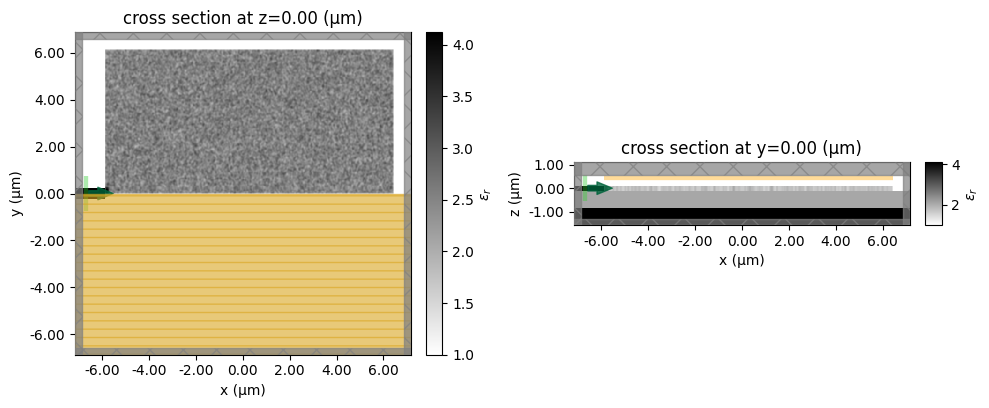

In [174]:
init_design = make_adjoint_sim(init_par, beta=beta_min)

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 10))
init_design.plot_eps(z=0, ax=ax1)
init_design.plot_eps(y=0, ax=ax2)
plt.show()

## Ideal Solution, Debug Plotting

In [175]:
def analytic_gaussian_beam(proj_monitor, r_proj, waist_radius):
    """
    Generates an analytical Gaussian beam pattern in a Tidy3D Far Field Data structure.
    """

    # Extract coordinates from the monitor
    x_coords = np.array(proj_monitor.x)
    y_coords = np.array(proj_monitor.y)
    z_dist = proj_monitor.proj_distance
    f0 = np.array(proj_monitor.freqs)[0]
    
    X, Y = np.meshgrid(x_coords - proj_monitor.custom_origin[0], 
                       y_coords - proj_monitor.custom_origin[1], 
                       indexing='ij')
    
    E_mag = np.exp(-(X**2 + Y**2) / (waist_radius**2))
    
    wavelength = td.C_0 / f0
    k = 2 * np.pi / wavelength
    phase = np.exp(1j * k * z_dist)

    Etheta_val = (E_mag * phase).reshape(len(x_coords), len(y_coords), 1, 1)

    # Package into Tidy3D DataArrays
    coords = dict(
        x=x_coords,
        y=y_coords,
        z=np.array([z_dist]),
        f=np.array([f0]),
    )
    
    Etheta_da = td.FieldProjectionCartesianDataArray(Etheta_val, coords=coords)
    zero_da = td.FieldProjectionCartesianDataArray(np.zeros_like(Etheta_val), coords=coords)

    return td.FieldProjectionCartesianData(
        monitor=proj_monitor,
        Er=zero_da,
        Etheta=Etheta_da,
        Ephi=zero_da,
        Hr=zero_da,
        Htheta=zero_da,
        Hphi=zero_da,
        projection_surfaces=proj_monitor.projection_surfaces,
    )

def make_field_plot(x, y, vals1, vals2):
    """
    Plots two field distributions side-by-side in Cartesian microns.
    Args:
        x, y: 1D arrays of spatial coordinates in microns.
        vals1, vals2: 2D arrays of field values (e.g., Ex, Ey, or Intensity).
    """
    n_plots = 2
    fig, ax = plt.subplots(1, n_plots, tight_layout=True, figsize=(10, 4.5))

    # Plotting first dataset (Analytic)
    im1 = ax[0].pcolormesh(
        x, 
        y, 
        np.real(vals1).T, # Transpose if meshgrid indexing='ij' was used
        cmap="RdBu", 
        shading="auto"
    )
    
    # Plotting second dataset (Simulation/Field Projection)
    im2 = ax[1].pcolormesh(
        x, 
        y, 
        np.real(vals2).T, 
        cmap="RdBu", 
        shading="auto"
    )
    
    # Formatting
    fig.colorbar(im1, ax=ax[0], label="Re(E)")
    fig.colorbar(im2, ax=ax[1], label="Re(E)")
    
    ax[0].set_title("Analytic Target")
    ax[1].set_title("Field Projection")
    
    for _ax in ax:
        _ax.set_xlabel(r"$x$ ($\mu$m)")
        _ax.set_ylabel(r"$y$ ($\mu$m)")
        _ax.set_aspect('equal') # Critical for seeing the true 2um circular shape
        
    plt.show()

## Objective Function

In [176]:
from tidy3d.plugins.autograd import make_erosion_dilation_penalty

erode_dilate_penalty = make_erosion_dilation_penalty(filter_radius, dr_grid_size)

# Figure of Merit (FOM) calculation.
def fom(sim_data: td.SimulationData, debug: bool = False) -> float:
    #Projects fields to 100um and calculates overlap with 2um Gaussian waist.
        
    # Define target focus plane coordinates
    num_pts = 100
    x_pts = np.linspace(dr_center_x - 5, dr_center_x + 5, num_pts)
    y_pts = np.linspace(-5, 5, num_pts)
    z_target = 100.0 

    monitor_far = td.FieldProjectionCartesianMonitor(
        center = field_near.center,
        size = (td.inf, td.inf, 0),
        freqs = [freq],
        name='monitor_far',
        far_field_approx=True,
        proj_distance=z_target,
        proj_axis=2,
        custom_origin=(dr_center_x, 0, 0),
        x=x_pts,
        y=y_pts,
    )

    # 1. Project fields from near-field monitor to target height
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data,
        near_monitors=[sim_data.simulation.monitors[0]],
        normal_dirs=["+"],
    )
    
    # Get projected E-fields on the plane
    proj_fields = projector.project_fields(monitor_far)
    E_actual = proj_fields.Etheta.isel(f=0, z=0) # Assuming TE-like polarization
    
    # 2. Define Ideal Gaussian Target (waist = 2.0 um)
    w0 = 2.0
    analytic_field_data = analytic_gaussian_beam(monitor_far, z_target, w0)
    E_analytic = analytic_field_data.Etheta.isel(f=0, z=0)
    
    # 3. Calculate Overlap Integral: |integral(E_act * E_ideal*)|^2 / (norm_act * norm_ideal)
    overlap = np.abs(np.sum(E_actual * np.conj(E_analytic)))**2
    norm = np.sum(np.abs(E_actual)**2) * np.sum(np.abs(E_analytic)**2)


    if debug:
        make_field_plot(x_pts, y_pts, E_actual.values, E_analytic.values)
    print(f"overlap: {overlap}")
    print(f"norm: {norm}")
    print(f"overlap/norm: {overlap/norm}")
    result = overlap/norm
    print(f"ndarray {result.to_numpy()}")
    numpy_result = result.to_numpy()
    print(f"ndarray data type {numpy_result.dtype}")
    print(f"ndarray shape {numpy_result.shape}")
    final_result = numpy_result.item()
    print(f"numpy result item {final_result}")
    return final_result


def penalty(params, beta) -> float:
    """Penalty function based on amount of change in parameters after erosion and dilation."""
    params_processed = pre_process(params, beta=beta)
    return erode_dilate_penalty(params_processed)

#latest_sim_data = None

# Objective function to be passed to the optimization algorithm.
def obj(design_param, beta: float = 1.0, step_num: int = None, verbose: bool = False) -> float:
    #global latest_sim_data
    sim = make_adjoint_sim(design_param, beta)
    task_name = "inv_des_farfield"
    if step_num:
        task_name += f"_step_{step_num}"
    sim_data = web.run(sim, task_name=task_name, verbose=verbose)
    #latest_sim_data = sim_data
    fom_val = fom(sim_data, debug=False)
    feature_size_penalty = penalty(design_param, beta=beta)
    J = fom_val - feature_size_penalty
    print(feature_size_penalty)
    return J


# Function to calculate the objective function value and its
# gradient with respect to the design parameters.
obj_grad = value_and_grad(obj)

In [177]:
"""
example_sim = make_adjoint_sim(init_par, beta=beta_min)

debug_sim_data = web.run(simulation=example_sim, task_name="debug_example", verbose=False)
fom_val = fom(debug_sim_data, debug=False)
"""

'\nexample_sim = make_adjoint_sim(init_par, beta=beta_min)\n\ndebug_sim_data = web.run(simulation=example_sim, task_name="debug_example", verbose=False)\nfom_val = fom(debug_sim_data, debug=False)\n'

# Optimization

## Check for previous optimization

In [178]:
import pickle

import optax

# hyperparameters
learning_rate = 0.2
optimizer = optax.adam(learning_rate=learning_rate)

# where to store history
history_fname = "misc/grating_coupler_history_autograd_projected.pkl"


def save_history(history_dict: dict) -> None:
    """Convenience function to save the history to file."""
    with open(history_fname, "wb") as file:
        pickle.dump(history_dict, file)


def load_history() -> dict:
    """Convenience method to load the history from file."""
    with open(history_fname, "rb") as file:
        history_dict = pickle.load(file)
    return history_dict

try:
    history_dict = load_history()
    opt_state = history_dict["opt_states"][-1]
    params = history_dict["params"][-1]
    num_iters_completed = len(history_dict["params"])
    print("Loaded optimization checkpoint from file.")
    print(f"Found {num_iters_completed} iterations previously completed out of {total_iter} total.")
    if num_iters_completed < total_iter:
        print("Will resume optimization.")
    else:
        print("Optimization completed, will return results.")

except FileNotFoundError:
    params = np.array(init_par)
    opt_state = optimizer.init(params)
    history_dict = dict(
        values=[],
        params=[],
        gradients=[],
        opt_states=[opt_state],
        data=[],
        beta=[],
    )

## Run Optimization

In [179]:
iter_done = len(history_dict["values"])

for i in range(iter_done, total_iter):
    print(f"iteration = ({i + 1} / {total_iter})")

    # compute gradient and current objective function value
    perc_done = i / (total_iter - 1)
    beta_i = beta_min * (1 - perc_done) + beta_max * perc_done
    value, gradient = obj_grad(params, beta=beta_i)

    #sim_data_i = latest_sim_data

    # outputs
    print(f"\tbeta = {beta_i}")
    print(f"\tJ = {value:.4e}")
    print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

    # compute and apply updates to the optimizer based on gradient (-1 sign to maximize obj_fn)
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params[:] = optax.apply_updates(params, updates)

    # cap parameters between 0 and 1
    np.clip(params, 0.0, 1.0, out=params)

    # save history
    history_dict["values"].append(value)
    history_dict["params"].append(params)
    history_dict["beta"].append(beta_i)
    history_dict["gradients"].append(gradient)
    history_dict["opt_states"].append(opt_state)
    #history_dict["data"].append(sim_data_i) # uncomment to store data, can create large files
    save_history(history_dict)

iteration = (1 / 41)


19:03:19 PST WARNING: Colocating data that has already been colocated during the
             solver run. For most accurate results when colocating to custom    
             coordinates set 'Monitor.colocate' to 'False' to use the raw data  
             on the Yee grid and avoid double interpolation. Note: the default  
             value was changed to 'True' in Tidy3D version 2.4.0.               

Output()

overlap: <xarray.DataArray ()> Size: 8B

Coordinates:
    z        float64 8B 100.0
    f        float64 8B 4.112e+14
norm: <xarray.DataArray ()> Size: 8B

Coordinates:
    z        float64 8B 100.0
    f        float64 8B 4.112e+14
overlap/norm: <xarray.DataArray ()> Size: 8B

Coordinates:
    z        float64 8B 100.0
    f        float64 8B 4.112e+14
ndarray Autograd ArrayBox with value 1.366760960430857e-33
ndarray data type object
ndarray shape ()
numpy result item Autograd ArrayBox with value 1.366760960430857e-33
Autograd ArrayBox with value 0.9998192740774725
	beta = 1.0
	J = -9.9982e-01
	grad_norm = 2.2135e-05
iteration = (2 / 41)


19:08:39 PST WARNING: Colocating data that has already been colocated during the
             solver run. For most accurate results when colocating to custom    
             coordinates set 'Monitor.colocate' to 'False' to use the raw data  
             on the Yee grid and avoid double interpolation. Note: the default  
             value was changed to 'True' in Tidy3D version 2.4.0.               

...

Output()

overlap: <xarray.DataArray ()> Size: 8B

Coordinates:
    z        float64 8B 100.0
    f        float64 8B 4.112e+14
norm: <xarray.DataArray ()> Size: 8B

Coordinates:
    z        float64 8B 100.0
    f        float64 8B 4.112e+14
overlap/norm: <xarray.DataArray ()> Size: 8B

Coordinates:
    z        float64 8B 100.0
    f        float64 8B 4.112e+14
ndarray Autograd ArrayBox with value 2.3337167215272517e-35
ndarray data type object
ndarray shape ()
numpy result item Autograd ArrayBox with value 2.3337167215272517e-35
Autograd ArrayBox with value 0.0212690470482383
	beta = 29.275
	J = -2.1269e-02
	grad_norm = 8.0046e-04
iteration = (41 / 41)


22:24:00 PST WARNING: Colocating data that has already been colocated during the
             solver run. For most accurate results when colocating to custom    
             coordinates set 'Monitor.colocate' to 'False' to use the raw data  
             on the Yee grid and avoid double interpolation. Note: the default  
             value was changed to 'True' in Tidy3D version 2.4.0.               

Output()

overlap: <xarray.DataArray ()> Size: 8B

Coordinates:
    z        float64 8B 100.0
    f        float64 8B 4.112e+14
norm: <xarray.DataArray ()> Size: 8B

Coordinates:
    z        float64 8B 100.0
    f        float64 8B 4.112e+14
overlap/norm: <xarray.DataArray ()> Size: 8B

Coordinates:
    z        float64 8B 100.0
    f        float64 8B 4.112e+14
ndarray Autograd ArrayBox with value 1.5382498300318044e-33
ndarray data type object
ndarray shape ()
numpy result item Autograd ArrayBox with value 1.5382498300318044e-33
Autograd ArrayBox with value 0.021220232413920386
	beta = 30.0
	J = -2.1220e-02
	grad_norm = 8.1666e-04


## Plot Objective Function Results

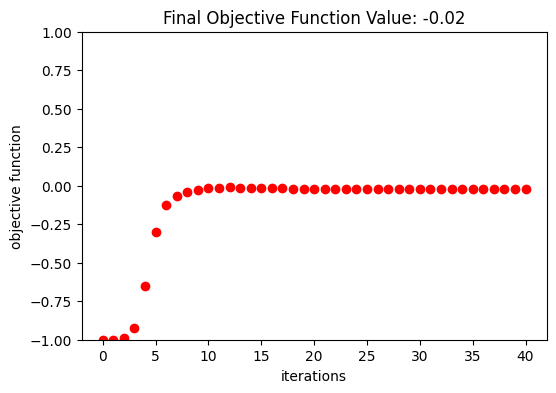

In [180]:
obj_vals = np.array(history_dict["values"])
final_par = history_dict["params"][-1]
final_beta = history_dict["beta"][-1]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(obj_vals, "ro")
ax.set_xlabel("iterations")
ax.set_ylabel("objective function")
ax.set_ylim(-1, 1)
ax.set_title(f"Final Objective Function Value: {obj_vals[-1]:.2f}")
plt.show()

## Plot Final Structure

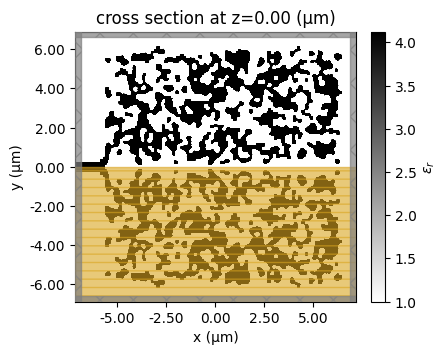

In [181]:
fig, ax = plt.subplots(1, figsize=(4, 4))
sim_final = make_adjoint_sim(final_par, beta=final_beta, unfold=True)
sim_final.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax)
plt.show()

Once the inverse design is complete, we can visualize the field distributions and the wavelength dependent coupling efficiency.

In [182]:
# Field monitors to visualize the final fields.
field_xy = td.FieldMonitor(
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="field_xy",
)

field_xz = td.FieldMonitor(
    size=(td.inf, 0, td.inf),
    freqs=[freq],
    name="field_xz",
)

# Monitor to compute the grating coupler efficiency.
mode_spec = td.ModeSpec(num_modes=1, target_neff=nSi3N4)
gc_efficiency = td.ModeMonitor(
    center=field_near.center,
    size=field_near.size,
    freqs=freqs,
    mode_spec=mode_spec,
    name="gc_efficiency",
)

sim_final = sim_final.copy(update=dict(monitors=(field_xy, field_xz, gc_efficiency, field_near)))
#sim_data_final = web.run(sim_final, task_name="inv_des_final")
job = web.Job(simulation=sim_final, task_name="inv_des_final")
estimated_cost = web.estimate_cost(job.task_id)
sim_data_final = job.run(path="data/farfield_final_sim.hdf5")

22:28:31 PST WARNING: Mode monitor 'gc_efficiency' has a large number (3.84e+05)
             of grid points. This can lead to solver slow-down and increased    
             cost. Consider making the size of the component smaller, as long as
             the modes of interest decay by the plane boundaries.               

22:28:32 PST Created task 'inv_des_final' with resource_id                      
             'fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=322687;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=654512;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\taskId]8;;\]8;id=322687;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\=]8;;\]8;id=251084;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\fdve]8;;\]8;id=322687;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\-b48c041d-b5b]8;;\
             ]8;id=322687;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\2-4a53-8d98-29030b3f925e']8;;\.

             Task folder: ]8;id=629629;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

...

Output()

22:29:32 PST status = success

22:29:34 PST View simulation result at                                          
             ]8;id=793921;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=477356;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\taskId]8;;\]8;id=793921;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\=]8;;\]8;id=917685;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\fdve]8;;\]8;id=793921;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\-b48c041d-b5b]8;;\
             ]8;id=793921;https://tidy3d.simulation.cloud/workbench?taskId=fdve-b48c041d-b5b2-4a53-8d98-29030b3f925e\2-4a53-8d98-29030b3f925e']8;;\.

Output()

22:29:36 PST Loading simulation from data/farfield_final_sim.hdf5

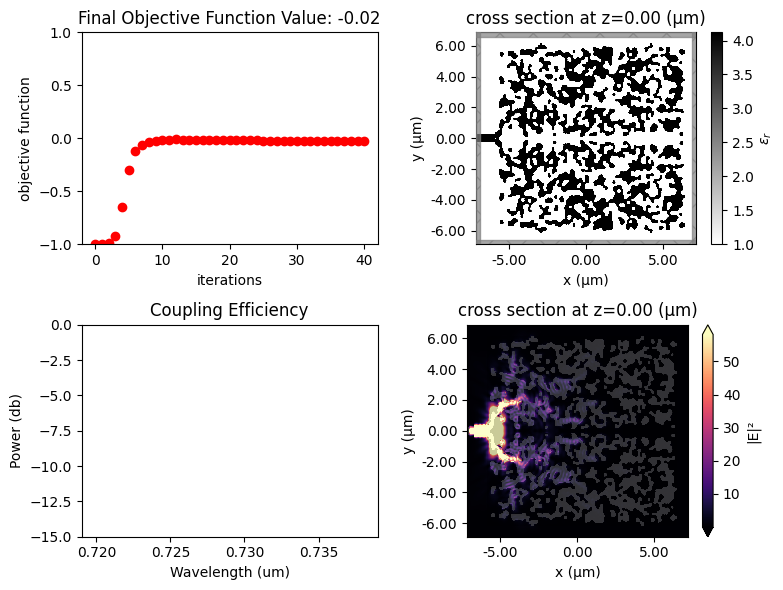

In [183]:
mode_amps = sim_data_final["gc_efficiency"]
coeffs_f = mode_amps.amps.sel(direction="+")
power_0 = np.abs(coeffs_f.sel(mode_index=0)) ** 2
power_0_db = 10 * np.log10(power_0)

sim_plot = sim_final.updated_copy(symmetry=(0, 0, 0), monitors=(field_xy, field_xz, gc_efficiency, field_near))
sim_data_plot = sim_data_final.updated_copy(simulation=sim_plot)

f, ax = plt.subplots(2, 2, figsize=(8, 6), tight_layout=True)
sim_plot.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax[0, 1])
ax[1, 0].plot(wl_range, power_0_db, "-k")
ax[1, 0].set_xlabel("Wavelength (um)")
ax[1, 0].set_ylabel("Power (db)")
ax[1, 0].set_ylim(-15, 0)
ax[1, 0].set_xlim(wl - bw / 2, wl + bw / 2)
ax[1, 0].set_title("Coupling Efficiency")
sim_data_plot.plot_field("field_xy", "E", "abs^2", z=0, ax=ax[1, 1])
ax[0, 0].plot(obj_vals, "ro")
ax[0, 0].set_xlabel("iterations")
ax[0, 0].set_ylabel("objective function")
ax[0, 0].set_ylim(-1, 1)
ax[0, 0].set_title(f"Final Objective Function Value: {obj_vals[-1]:.2f}")
plt.show()

In [184]:
loss_db = max(power_0_db)
print(f"optimized loss of {loss_db:.2f} dB")

optimized loss of -46.20 dB


## Visualize Farfields

23:38:10 PST WARNING: Colocating data that has already been colocated during the
             solver run. For most accurate results when colocating to custom    
             coordinates set 'Monitor.colocate' to 'False' to use the raw data  
             on the Yee grid and avoid double interpolation. Note: the default  
             value was changed to 'True' in Tidy3D version 2.4.0.               

Output()

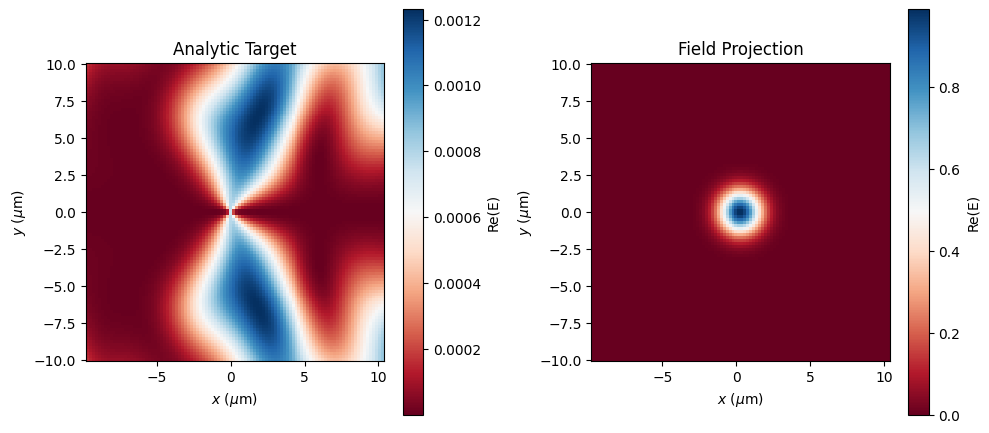

In [192]:
num_pts = 100
x_pts = np.linspace(dr_center_x - 10, dr_center_x + 10, num_pts)
y_pts = np.linspace(-10, 10, num_pts)
z_target = 100.0 

monitor_far = td.FieldProjectionCartesianMonitor(
    center = field_near.center,
    size = (td.inf, td.inf, 0),
    freqs = [freq],
    name='monitor_far',
    far_field_approx=True,
    proj_distance=z_target,
    proj_axis=2,
    custom_origin=(dr_center_x, 0, 0),
    x=x_pts,
    y=y_pts,
)

projector = td.FieldProjector.from_near_field_monitors(
    sim_data=sim_data_final,
    near_monitors=[sim_data_final.simulation.monitors[3]],
    normal_dirs=["+"],
)

# Get projected E-fields on the plane
proj_fields = projector.project_fields(monitor_far)
E_actual = proj_fields.Etheta.isel(f=0, z=0) # Assuming TE-like polarization
E_actual_intensity = (np.abs(E_actual))**2

# 2. Define Ideal Gaussian Target (waist = 2.0 um)
w0 = 2.0
analytic_field_data = analytic_gaussian_beam(monitor_far, z_target, w0)
E_analytic = analytic_field_data.Etheta.isel(f=0, z=0)
E_analytic_intensity = (np.abs(E_analytic))**2

make_field_plot(x_pts, y_pts, E_actual_intensity.values, E_analytic_intensity.values)

In [186]:
E_cartesian = proj_fields.fields_cartesian
print(E_cartesian.dims)
print(E_cartesian)

FrozenMappingWarningOnValuesAccess({'x': 100, 'y': 100, 'z': 1, 'f': 1})
<xarray.Dataset> Size: 962kB
Dimensions:  (x: 100, y: 100, z: 1, f: 1)
Coordinates:
  * x        (x) float64 800B -9.719 -9.517 -9.315 -9.113 ... 9.877 10.08 10.28
  * y        (y) float64 800B -10.0 -9.798 -9.596 -9.394 ... 9.596 9.798 10.0
  * z        (z) float64 8B 20.0
  * f        (f) float64 8B 4.112e+14
Data variables:
    Ex       (x, y, z, f) complex128 160kB (-0.012187955071546656+0.037699650...
    Ey       (x, y, z, f) complex128 160kB (-0.007521373999011831-0.001038045...
    Ez       (x, y, z, f) complex128 160kB (-0.009683240947197939+0.017800556...
    Hx       (x, y, z, f) complex128 160kB (2.691933298510282e-05-1.711932038...
    Hy       (x, y, z, f) complex128 160kB (-3.678385062478024e-05+0.00010092...
    Hz       (x, y, z, f) complex128 160kB (-5.3108792382741775e-06+4.2142172...


## Export to GDS
The `Simulation` object has the [.to_gds_file](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html#tidy3d.Simulation.to_gds_file) convenience function to export the final design to a `GDS` file. In addition to a file name, it is necessary to set a cross-sectional plane (`z = 0` in this case) on which to evaluate the geometry, a `frequency` to evaluate the permittivity, and a `permittivity_threshold` to define the shape boundaries in custom mediums. See the [GDS export](https://www.flexcompute.com/tidy3d/examples/notebooks/GDSExport/) notebook for a detailed example on using `.to_gds_file` and other GDS related functions.

In [187]:
sim_final.to_gds_file(
    fname="./misc/inverse_designed_gc.gds",
    z=0,
    permittivity_threshold=(eps_max + eps_min) / 2,
    frequency=freq,
)